In [2]:
# ================================================================
# Step 1: Import Libraries
# ================================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial import Delaunay
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.metrics import roc_curve, auc

In [3]:
from google.colab import files

In [4]:
# ================================================================
# Step 2: Load Dataset
# ================================================================
from google.colab import files
uploaded = files.upload()

Saving Pharma_Industry.csv to Pharma_Industry (1).csv


In [5]:
import pandas as pd
df = pd.read_csv('Pharma_Industry.csv')

In [6]:
df.shape

(500, 6)

In [7]:
df.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


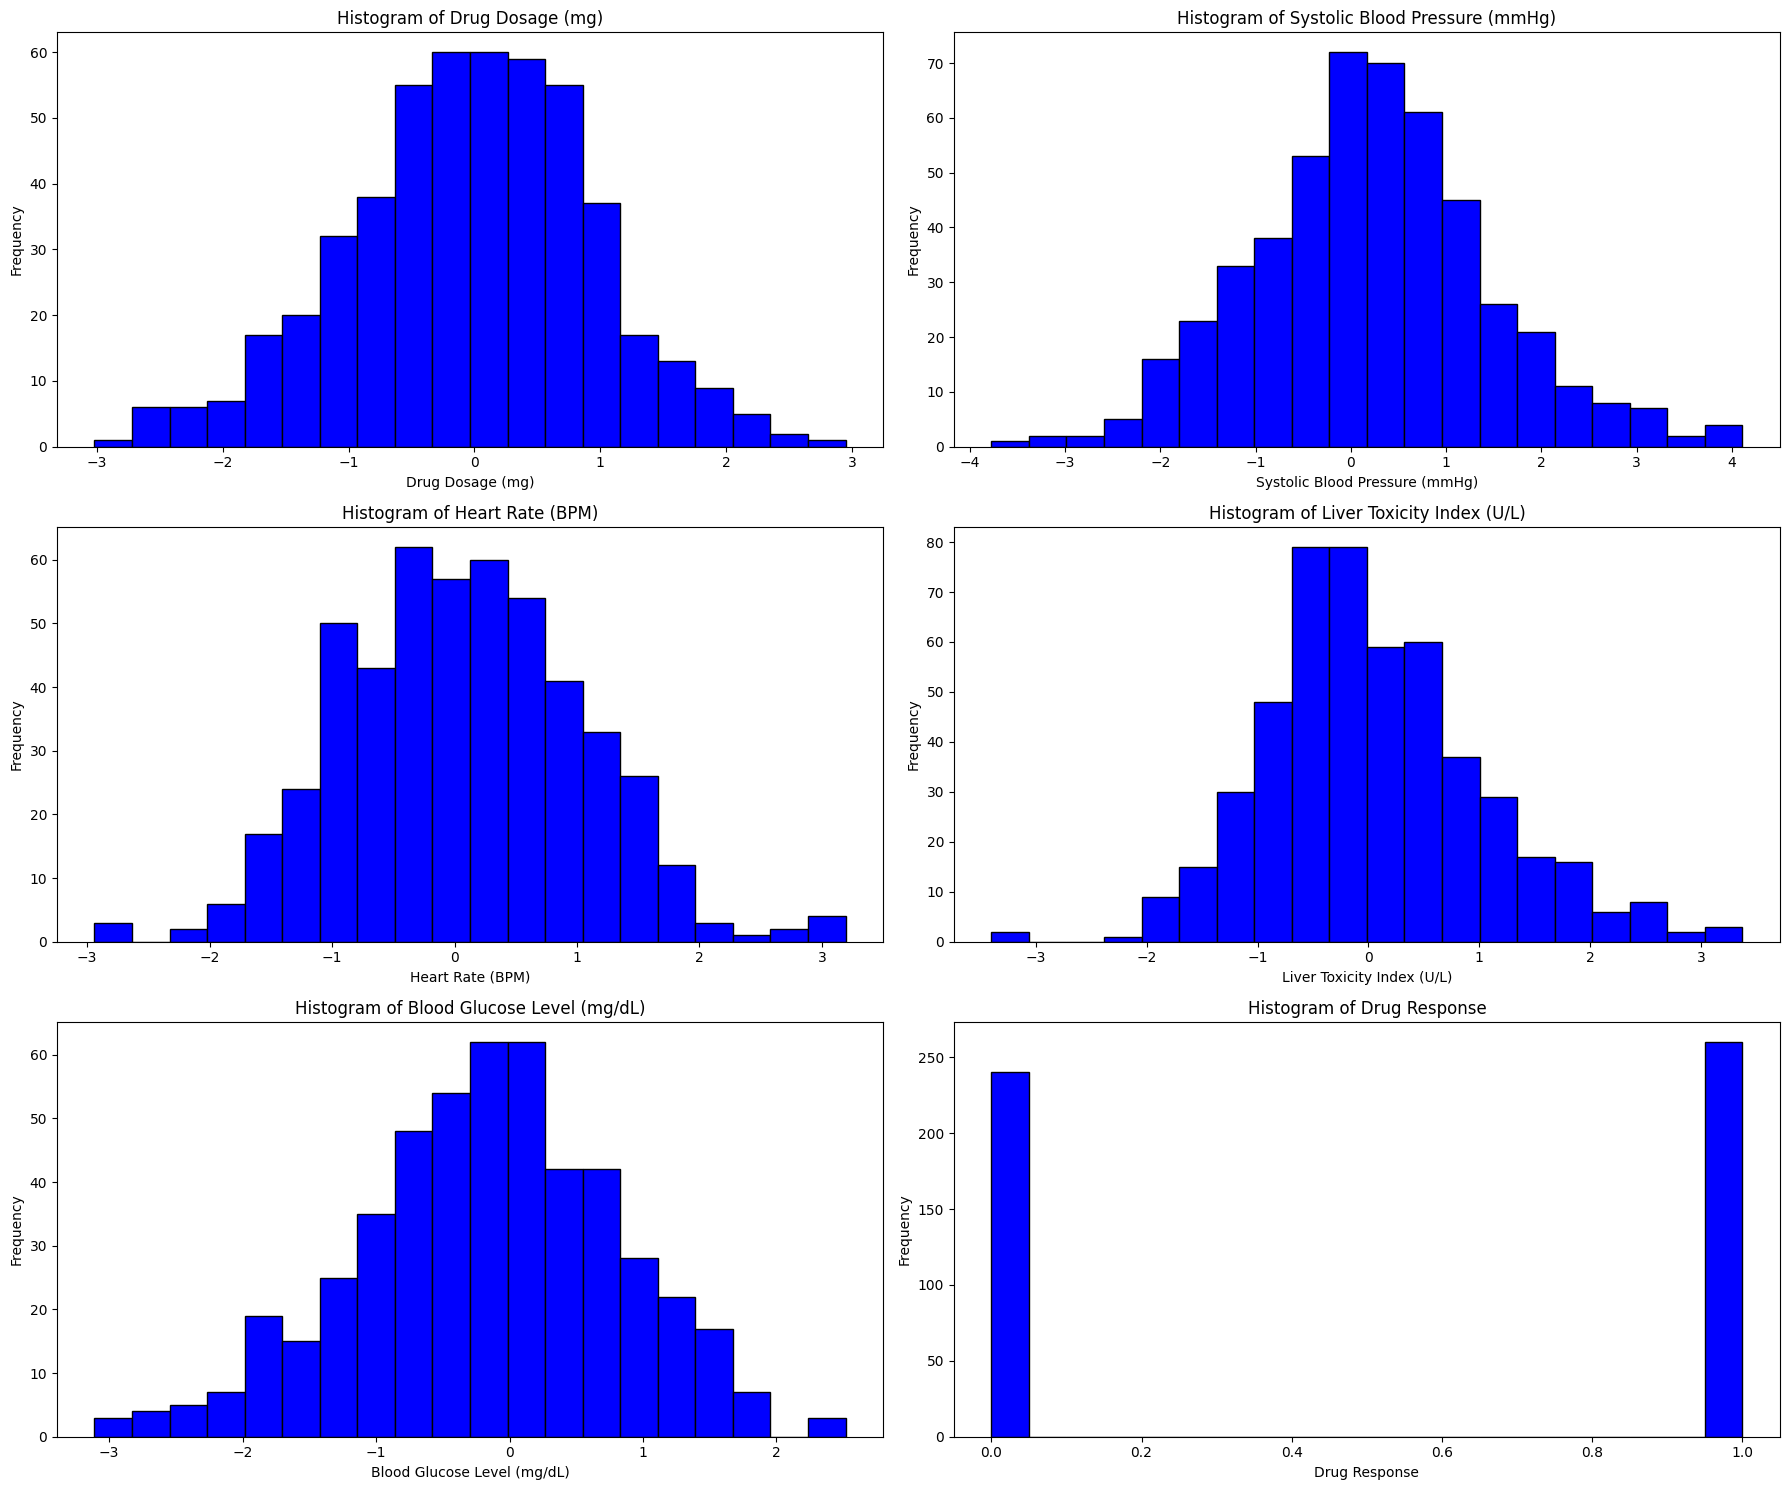

In [8]:
fig, axes = plt.subplots(3, 2, figsize=(18, 15))

# Flatten the 2D axis array to make it easier to iterate
axes = axes.flatten()

# Loop through each numeric column and plot its histogram
for i, col in enumerate(df):
    axes[i].hist(df[col], bins=20, color='blue', edgecolor='black')
    axes[i].set_title(f'Histogram of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

In [9]:
print(f"Null values: \n{df.isna().sum()}") #Identifying Null or Nan rows in the Data Frame
df.loc[df.isna().any(axis=1)]

Null values: 
Drug Dosage (mg)                  0
Systolic Blood Pressure (mmHg)    0
Heart Rate (BPM)                  0
Liver Toxicity Index (U/L)        0
Blood Glucose Level (mg/dL)       0
Drug Response                     0
dtype: int64


,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response


In [10]:
print(f" Duplicates: {df.duplicated().sum()}")

 Duplicates: 0


All **independent paramters** or variables are numeric columns and continuous  values. And there are no null or duplicate records. The data looks almost normally distributed. The numerical data is in a **scaled standarised** format and hence, doesnot require any scaling.

In [11]:
df.describe()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,-0.037761,0.214957,0.062871,0.054398,-0.171863,0.5200
std,0.979891,1.247567,0.971978,0.986001,0.983765,0.5001
min,-3.019512,-3.773897,-2.940389,-3.401277,-3.110431,0.0000
25%,-0.642003,-0.565168,-0.648157,-0.586085,-0.797715,0.0000
50%,-0.019340,0.201532,0.027732,-0.065661,-0.108106,1.0000
75%,0.641151,0.951375,0.710774,0.633914,0.513555,1.0000
max,2.949094,4.111751,3.193108,3.373269,2.518023,1.0000


In [12]:
df.rename(columns={'Drug Dosage (mg)': 'Drug_Dosage', 'Systolic Blood Pressure (mmHg)': 'Blood_Pressure','Heart Rate (BPM)':'Heart_Rate','Liver Toxicity Index (U/L)':'Liver_Toxic_Index','Blood Glucose Level (mg/dL)':'Blood_Glucose','Drug Response':'Drug_Response'}, inplace=True)

Text(0.5, 1.0, 'Box Plot for each Variable')

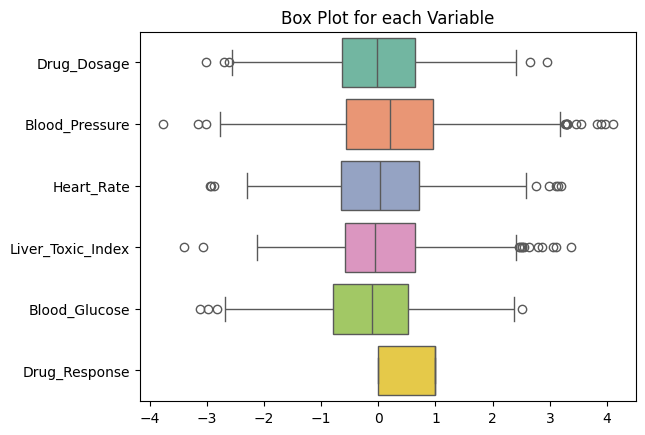

In [13]:
ax = sns.boxplot(data=df, orient="h", palette="Set2")
plt.title('Box Plot for each Variable')

<Axes: xlabel='Drug_Response', ylabel='count'>

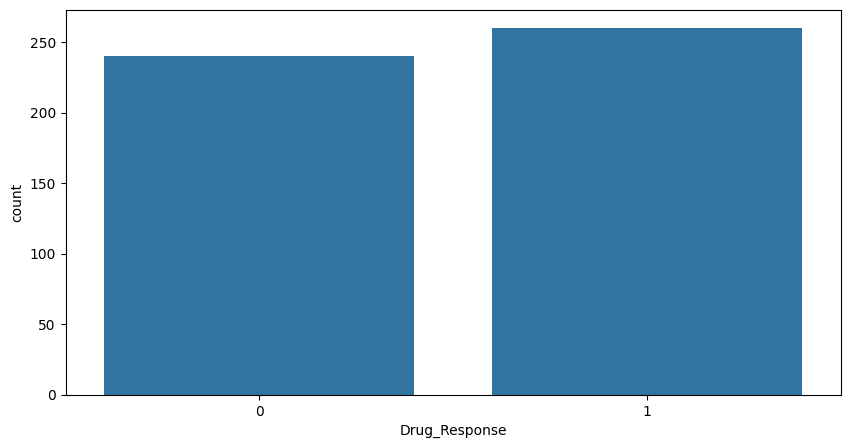

In [14]:
fig = plt.figure(figsize=(10,5))
sns.countplot(x="Drug_Response", data=df)

Classification data is equally distributed for the two response classes in the Data set.There is **no imbalance** in the classes.

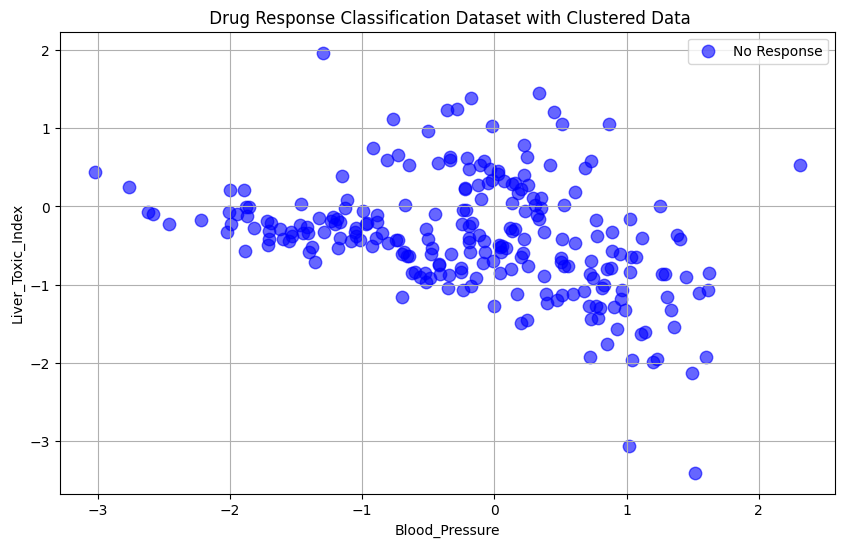

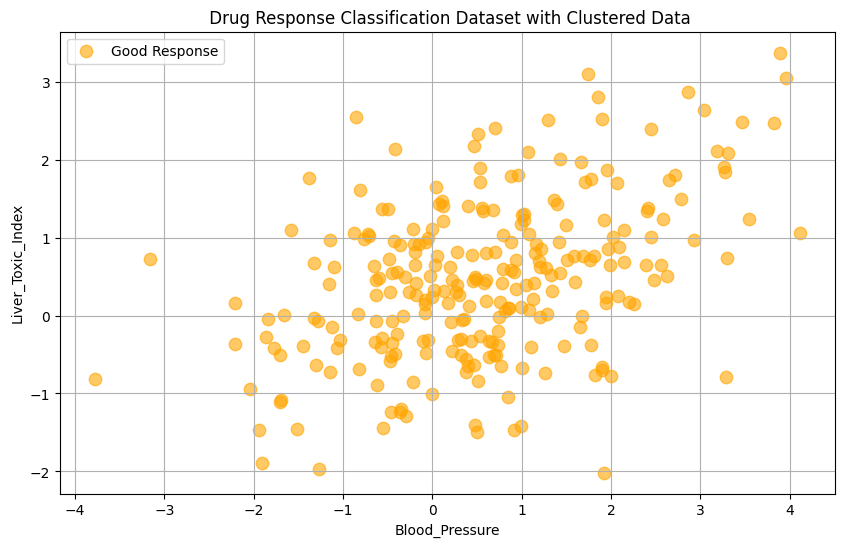

In [15]:
from pandas.core.groupby.generic import DataFrameGroupBy
# Create a scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(
    df[df["Drug_Response"] == 0]["Blood_Pressure"],
    df[df["Drug_Response"] == 0]["Liver_Toxic_Index"],
    label="No Response",
    color="blue",
    alpha=0.6,
    s=80,
)


# Set plot labels and title
plt.xlabel("Blood_Pressure")
plt.ylabel("Liver_Toxic_Index")
plt.title(" Drug Response Classification Dataset with Clustered Data")

# Add a legend
plt.legend()

# Show the plot
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(
    df[df["Drug_Response"] == 1]["Blood_Pressure"],
    df[df["Drug_Response"] == 1]["Liver_Toxic_Index"],
    label="Good Response",
    color="orange",
    alpha=0.6,
    s=80,
)

# Set plot labels and title
plt.xlabel("Blood_Pressure")
plt.ylabel("Liver_Toxic_Index")
plt.title(" Drug Response Classification Dataset with Clustered Data")

# Add a legend
plt.legend()

# Show the plot
plt.grid(True)
plt.show()


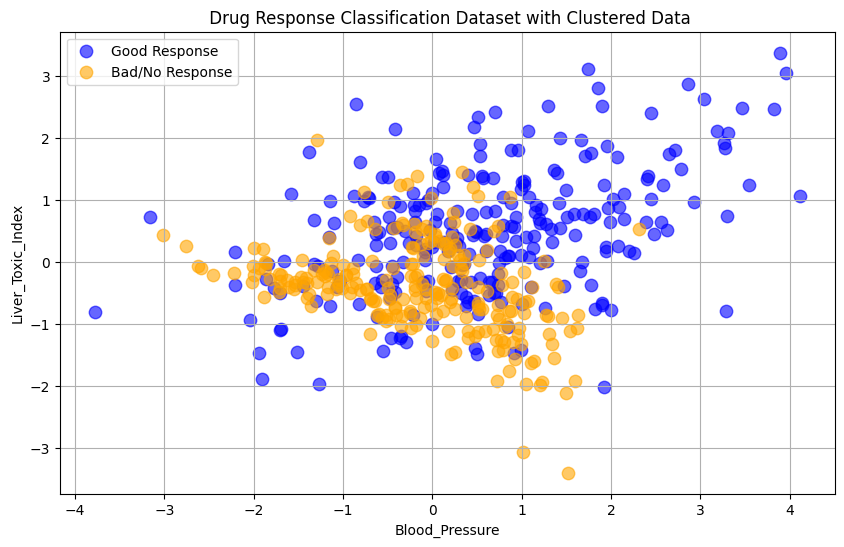

In [16]:
plt.figure(figsize=(10, 6))
plt.scatter(
    df[df["Drug_Response"] == 1]["Blood_Pressure"],
    df[df["Drug_Response"] == 1]["Liver_Toxic_Index"],
    label="Good Response",
    color = 'Blue',
    alpha=0.6,
    s=80,
)

plt.scatter(
    df[df["Drug_Response"] == 0]["Blood_Pressure"],
    df[df["Drug_Response"] == 0]["Liver_Toxic_Index"],
    label="Bad/No Response",
    color = 'orange',
    alpha=0.6,
    s=80,
)

# Set plot labels and title
plt.xlabel("Blood_Pressure")
plt.ylabel("Liver_Toxic_Index")
plt.title(" Drug Response Classification Dataset with Clustered Data")

# Add a legend
plt.legend()

# Show the plot
plt.grid(True)
plt.show()

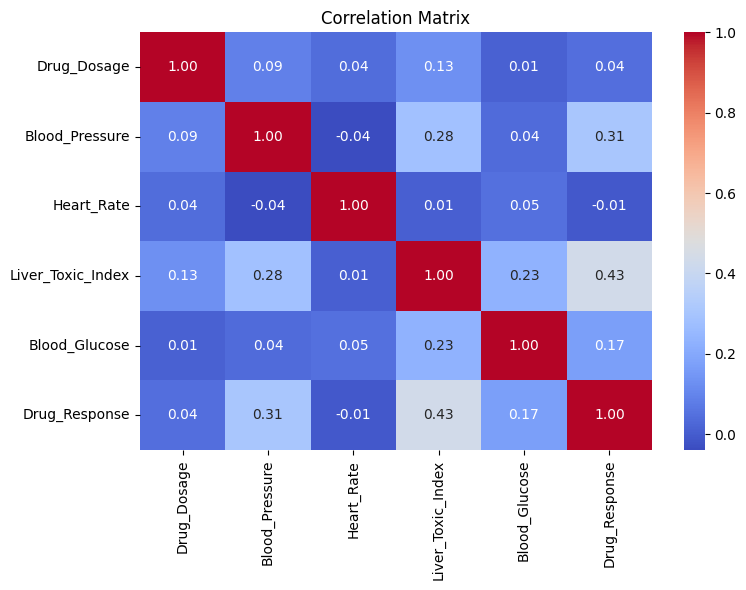

In [17]:
# Correlation Heatmap
correlation_matrix = df.corr()
# Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

The Drug Response Classification is moderately correlated with Liver Toxicity Index (0.43) and Liver Function(0.31).

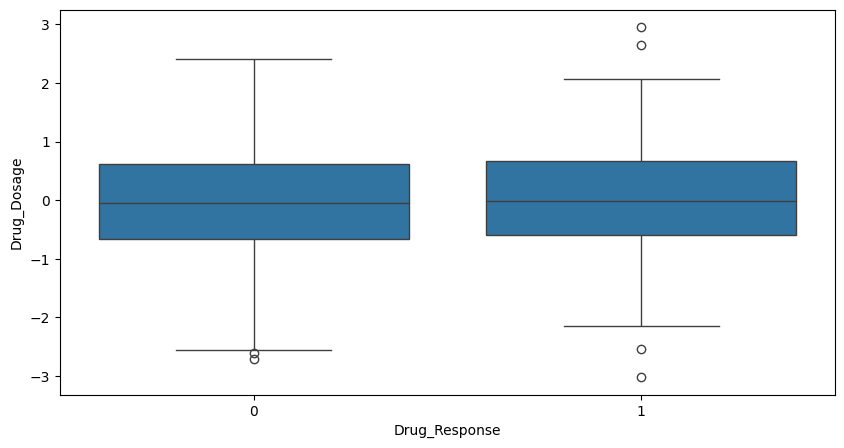

In [18]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(x="Drug_Response", y="Drug_Dosage", data=df)
plt.show()

For the same dosage of drugs the response is different. Lets check other parameters as well.

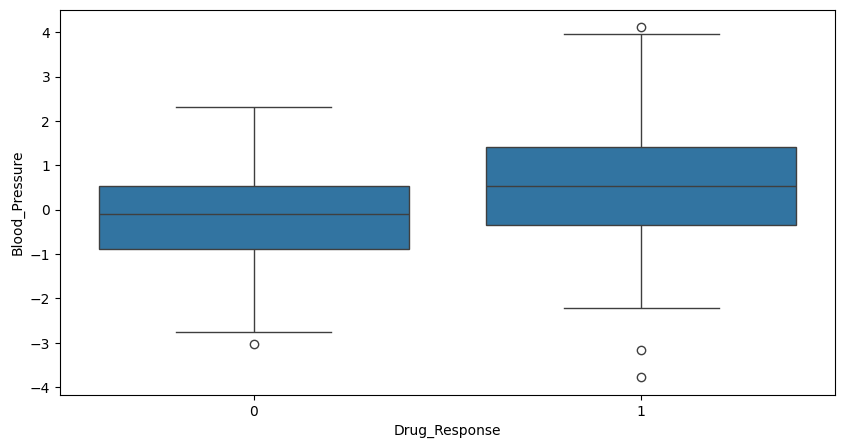

In [19]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(x="Drug_Response", y="Blood_Pressure", data=df)
plt.show()

Lower Systolic Blood Pressure levels showed no or less sigificant effect on the patients. Higher Blood Pressure levels had better or beneficial effect on the patients. There is a very moderate correlation of 0.31 between the Drug Response and Blood Pressure Level.

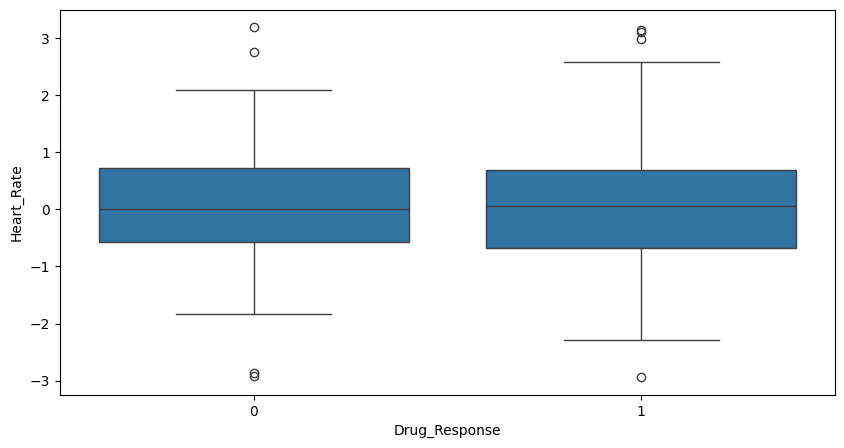

In [20]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(x="Drug_Response", y="Heart_Rate", data=df)
plt.show()

There is no correlation between the Drug Response and Heart Rate.

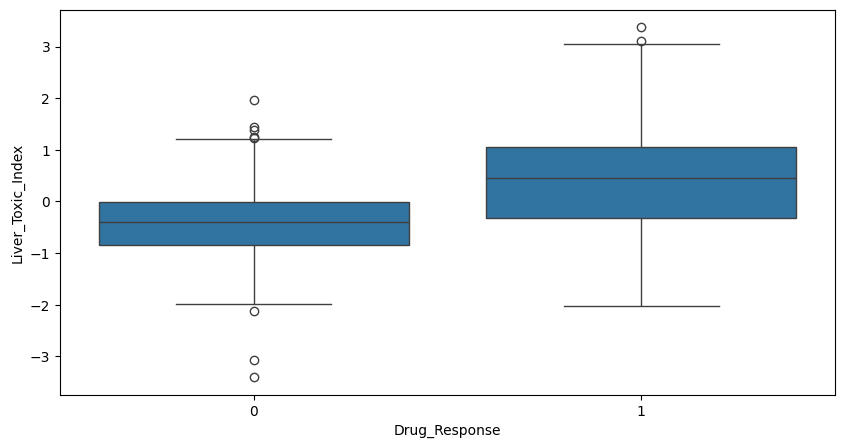

In [21]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(x="Drug_Response", y="Liver_Toxic_Index", data=df)
plt.show()

There is a moderate correlation between the Liver Toxic Index and Drug Response Classification. Higher values of Liver Toxic index show significant Drug response.

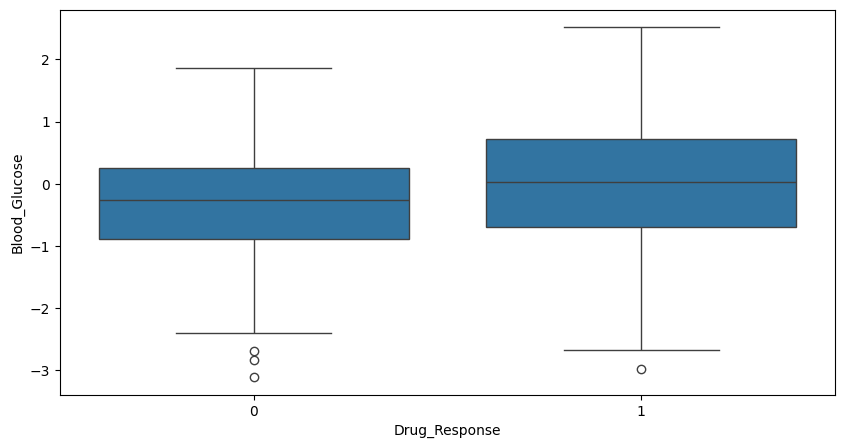

In [22]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(x="Drug_Response", y="Blood_Glucose", data=df)
plt.show()

Blood Glucose doesnot show much of a correlation with Drug Response.

In [23]:
df.columns

Index(['Drug_Dosage', 'Blood_Pressure', 'Heart_Rate', 'Liver_Toxic_Index',
       'Blood_Glucose', 'Drug_Response'],
      dtype='object')

In [24]:
df_param = df[['Drug_Dosage', 'Blood_Pressure', 'Heart_Rate', 'Liver_Toxic_Index','Blood_Glucose']]
df_param.head()

,Drug_Dosage,Blood_Pressure,Heart_Rate,Liver_Toxic_Index,Blood_Glucose
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355
4,0.377100,0.538410,-0.029263,1.896015,-0.960130


In [25]:


def get_outlier_thresholds_iqr(dataframe, col_name, th1=0.20, th3=0.80):
    quartile1 = dataframe[col_name].quantile(th1)
    quartile3 = dataframe[col_name].quantile(th3)
    iqr = quartile3 - quartile1
    upper_limit = quartile3 + 1.5 * iqr
    lower_limit = quartile1 - 1.5 * iqr
    return lower_limit, upper_limit

def check_outliers_iqr(dataframe, col_name):
    lower_limit, upper_limit = get_outlier_thresholds_iqr(dataframe, col_name)
    if dataframe[(dataframe[col_name] > upper_limit) | (dataframe[col_name] < lower_limit)].any(axis=None):
        return True
    else:
        return False

def replace_with_thresholds_iqr(dataframe,cols, th1=0.20, th3=0.80, replace=False):
    from tabulate import tabulate
    data = []
    for col_name in cols:
        outliers = check_outliers_iqr(df,col_name)
        count = None
        lower_limit, upper_limit = get_outlier_thresholds_iqr(dataframe, col_name, th1, th3)
        if outliers:
            count = dataframe[(dataframe[col_name] > upper_limit) | (dataframe[col_name] < lower_limit)][col_name].count()
            if replace:
                dataframe.loc[(dataframe[col_name] < lower_limit), col_name] = dataframe[col_name].median()
                dataframe.loc[(dataframe[col_name] > upper_limit), col_name] = dataframe[col_name].median()
        outliers_status = check_outliers_iqr(df, col_name)
        data.append([outliers, outliers_status, count, col_name, lower_limit, upper_limit ])
    table = tabulate(data, headers=['Outliers (Previously)', 'Outliers', 'Count', 'Column', 'Lower Limit', 'Upper Limit'], tablefmt='rst', numalign='right')
    print("Removing Outliers using IQR")
    print(table)

replace_with_thresholds_iqr(df_param, df_param.columns ,replace = False)

Removing Outliers using IQR
=======================  ==========  =======  =================  =============  =============
Outliers (Previously)    Outliers      Count  Column               Lower Limit    Upper Limit
=======================  ==========  =======  =================  =============  =============
False                    False                Drug_Dosage             -3.18265        3.09599
True                     True              2  Blood_Pressure          -3.60134        3.96485
False                    False                Heart_Rate              -3.32702        3.41172
True                     True              4  Liver_Toxic_Index       -2.99122        3.08287
False                    False                Blood_Glucose           -3.36928        3.08162
=======================  ==========  =======  =================  =============  =============


Outliers are in the Blood Pressure and Liver Toxic Index column for a threshold of 80 and 20.

In [26]:
df_val = pd.DataFrame(columns = ['Column Name','Mean','Median','Stddev','Minimum','Maximum','Mode'])
for columns in  df_param.columns:
   df_val.loc[len(df_val)] = [columns,df_param[columns].mean(),df_param[columns].median(),df_param[columns].std(),min(df_param[columns]),max(df_param[columns]),list(df_param[columns].mode())]

df_val

,Column Name,Mean,Median,Stddev,Minimum,Maximum,Mode
0,Drug_Dosage,-0.037761,-0.019340,0.979891,-3.019512,2.949094,"[-3.0195121558208253, -2.703232292999237, -2.6..."
1,Blood_Pressure,0.214957,0.201532,1.247567,-3.773897,4.111751,"[-3.773896544445874, -3.154520320876804, -3.01..."
2,Heart_Rate,0.062871,0.027732,0.971978,-2.940389,3.193108,"[-2.94038863466428, -2.921350483494608, -2.872..."
3,Liver_Toxic_Index,0.054398,-0.065661,0.986001,-3.401277,3.373269,"[-3.4012766020595318, -3.0678643865364443, -2...."
4,Blood_Glucose,-0.171863,-0.108106,0.983765,-3.110431,2.518023,"[-3.110430509816211, -2.976187601251005, -2.82..."


In [27]:
df_param.loc[(df_param['Blood_Pressure'] < -3.60134 ) | (df_param['Blood_Pressure'] > 3.96485 ) ]

,Drug_Dosage,Blood_Pressure,Heart_Rate,Liver_Toxic_Index,Blood_Glucose
204,0.683569,4.111751,-1.365956,1.054707,-0.143651
478,0.570613,-3.773897,0.968185,-0.818653,0.722850


In [28]:
df_param.loc[(df_param['Liver_Toxic_Index'] < -2.99122) | (df_param['Liver_Toxic_Index'] > 3.08287 ) ]

,Drug_Dosage,Blood_Pressure,Heart_Rate,Liver_Toxic_Index,Blood_Glucose
48,0.200569,1.018626,1.148637,-3.067864,-3.110431
89,1.124353,3.889688,-0.334077,3.373269,-1.078898
109,0.225308,1.740834,-0.369527,3.104773,-0.808180
412,0.998311,1.518578,-0.431620,-3.401277,-2.829083


Replacing outlier ( Threshold held at 80 and 20) with the median values for Blood_Pressure and Liver Toxic Index.

In [29]:
replace_with_thresholds_iqr(df_param, df_param.columns ,replace = True)

Removing Outliers using IQR
=======================  ==========  =======  =================  =============  =============
Outliers (Previously)    Outliers      Count  Column               Lower Limit    Upper Limit
=======================  ==========  =======  =================  =============  =============
False                    False                Drug_Dosage             -3.18265        3.09599
True                     True              2  Blood_Pressure          -3.60134        3.96485
False                    False                Heart_Rate              -3.32702        3.41172
True                     True              4  Liver_Toxic_Index       -2.99122        3.08287
False                    False                Blood_Glucose           -3.36928        3.08162
=======================  ==========  =======  =================  =============  =============


/tmp/ipython-input-2266885438.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe.loc[(dataframe[col_name] < lower_limit), col_name] = dataframe[col_name].median()
/tmp/ipython-input-2266885438.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe.loc[(dataframe[col_name] > upper_limit), col_name] = dataframe[col_name].median()
/tmp/ipython-input-2266885438.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  datafr

In [30]:
'''
# Get the index of rows to drop based on Blood_Pressure and Liver_Toxic_Index Outliers
rows_to_drop = df_param[(df_param['Blood_Pressure'] < -3.60134 ) | (df_param['Blood_Pressure'] > 3.96485 )].index

# Drop these rows
df_param.drop(rows_to_drop, axis = 0 , inplace=True)
df.drop(rows_to_drop, axis = 0 , inplace=True)

rows_to_drop = df_param.loc[(df_param['Liver_Toxic_Index'] < -2.99122) | (df_param['Liver_Toxic_Index'] > 3.08287 ) ].index

# Drop these rows from
df_param.drop(rows_to_drop, axis = 0 , inplace=True)
df.drop(rows_to_drop, axis = 0 , inplace=True)'''

"\n# Get the index of rows to drop based on Blood_Pressure and Liver_Toxic_Index Outliers\nrows_to_drop = df_param[(df_param['Blood_Pressure'] < -3.60134 ) | (df_param['Blood_Pressure'] > 3.96485 )].index\n\n# Drop these rows\ndf_param.drop(rows_to_drop, axis = 0 , inplace=True)\ndf.drop(rows_to_drop, axis = 0 , inplace=True)\n\nrows_to_drop = df_param.loc[(df_param['Liver_Toxic_Index'] < -2.99122) | (df_param['Liver_Toxic_Index'] > 3.08287 ) ].index\n\n# Drop these rows from\ndf_param.drop(rows_to_drop, axis = 0 , inplace=True)\ndf.drop(rows_to_drop, axis = 0 , inplace=True)"

In [31]:
df_param.loc[(df_param['Liver_Toxic_Index'] < -2.99122) | (df_param['Liver_Toxic_Index'] > 3.08287 ) ]

,Drug_Dosage,Blood_Pressure,Heart_Rate,Liver_Toxic_Index,Blood_Glucose


In [32]:
df_param.loc[(df_param['Blood_Pressure'] < -3.60134 ) | (df_param['Blood_Pressure'] > 3.96485 ) ]

,Drug_Dosage,Blood_Pressure,Heart_Rate,Liver_Toxic_Index,Blood_Glucose


In [33]:
df_val = pd.DataFrame(columns = ['Column Name','Mean','Median','Stddev','Minimum','Maximum','Mode'])
for columns in  df_param.columns:
   df_val.loc[len(df_val)] = [columns,df_param[columns].mean(),df_param[columns].median(),df_param[columns].std(),min(df_param[columns]),max(df_param[columns]),list(df_param[columns].mode())]

df_val

,Column Name,Mean,Median,Stddev,Minimum,Maximum,Mode
0,Drug_Dosage,-0.037761,-0.019340,0.979891,-3.019512,2.949094,"[-3.0195121558208253, -2.703232292999237, -2.6..."
1,Blood_Pressure,0.215087,0.201547,1.222337,-3.154520,3.961330,"[-3.154520320876804, -3.019457717363439, -2.76..."
2,Heart_Rate,0.062871,0.027732,0.971978,-2.940389,3.193108,"[-2.94038863466428, -2.921350483494608, -2.872..."
3,Liver_Toxic_Index,0.053857,-0.065346,0.942403,-2.123601,3.050811,"[-0.0656605572232225, -0.0650308055244565]"
4,Blood_Glucose,-0.171863,-0.108106,0.983765,-3.110431,2.518023,"[-3.110430509816211, -2.976187601251005, -2.82..."


In [34]:
# ================================================================
# Prepare Data
# ================================================================
X = df_param.iloc[:, 0:5]
y = df["Drug_Response"]

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
# ================================================================
#Train and Evaluate SVM Models with Different Kernels
# ================================================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


svm_linear = SVC(kernel='linear', C=1.0)
svm_poly = SVC(kernel='poly', degree=3, C=1.0)
svm_rbf = SVC(kernel='rbf', gamma=1, C=1.0)

# Train models
svm_linear.fit(X_train, y_train)
svm_poly.fit(X_train, y_train)
svm_rbf.fit(X_train, y_train)

# Predictions
y_pred_linear = svm_linear.predict(X_test)
y_pred_poly = svm_poly.predict(X_test)
y_pred_rbf = svm_rbf.predict(X_test)

# Calculate accuracy
accuracy_linear = accuracy_score(y_test, y_pred_linear)
accuracy_poly = accuracy_score(y_test, y_pred_poly)
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)

# Calculate precision
precision_linear = precision_score(y_test, y_pred_linear)
precision_poly = precision_score(y_test, y_pred_poly)
precision_rbf = precision_score(y_test, y_pred_rbf)


# Calculate recall (sensitivity)
recall_linear = recall_score(y_test, y_pred_linear)
recall_poly = recall_score(y_test, y_pred_poly)
recall_rbf = recall_score(y_test, y_pred_rbf)


# Calculate F1-score
f1_linear = f1_score(y_test, y_pred_linear)
f1_poly = f1_score(y_test, y_pred_poly)
f1_rbf = f1_score(y_test, y_pred_rbf)



# Display results
print(f"Linear SVM Accuracy: {accuracy_linear:.2f}")
print("Linear Precision:", precision_linear)
print("Linear Recall (Sensitivity):", recall_linear)
print("Linear F1-Score:", f1_linear)
print("\n")
print(f"Poly Polynomial SVM Accuracy: {accuracy_poly:.2f}")
print("Poly Precision:", precision_poly)
print("Poly Recall (Sensitivity):", recall_poly)
print("Poly F1-Score:", f1_poly)
print("\n")
print(f"RBF SVM Accuracy: {accuracy_rbf:.2f}")
print("RBF Precision:", precision_rbf)
print("RBF Recall (Sensitivity):", recall_rbf)
print("RBF F1-Score:", f1_rbf)



Linear SVM Accuracy: 0.77
Linear Precision: 0.8367346938775511
Linear Recall (Sensitivity): 0.7321428571428571
Linear F1-Score: 0.780952380952381


Poly Polynomial SVM Accuracy: 0.76
Poly Precision: 0.8478260869565217
Poly Recall (Sensitivity): 0.6964285714285714
Poly F1-Score: 0.7647058823529411


RBF SVM Accuracy: 0.78
RBF Precision: 0.8035714285714286
RBF Recall (Sensitivity): 0.8035714285714286
RBF F1-Score: 0.8035714285714286


Above listed are the precision,recall and F1-score of the different SVM algorithms.

**Precision**

Out of all the positive predicted, what percentage is truly positive.
The precision value lies between 0 and 1.

True Positive/(True Positive + False Positive)

**Recall**

Out of the total positive, what percentage are predicted positive. It is the same as TPR (true positive rate).

True Positive/( True Positive + False Negative).

In the medical application, we generally focus on not missing any patient. Therefore we focus on having a high recall. (False Negative should be low)

Recall has highest value of 0.803 for Radial Basis Function.

The F1 score is the harmonic mean of precision and recall, which makes it sensitive to small values. If either precision or recall is significantly lower than the other, it will have a more pronounced impact on the F1 score.
F1-score is useful for imbalanced datasets.

In this classification case, the data set is balanced.

In [36]:
test_df = pd.DataFrame(
    {'True': y_test, 'Linear': y_pred_linear, 'Polynomial': y_pred_poly, 'RBF' : y_pred_rbf})

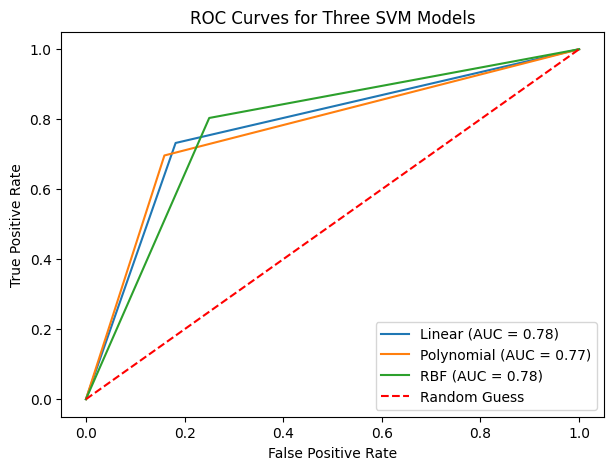

In [37]:
plt.figure(figsize=(7, 5))

for model in ['Linear', 'Polynomial','RBF']:
    fpr, tpr, _ = roc_curve(test_df['True'], test_df[model])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'r--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Three SVM Models')
plt.legend()
plt.show()

**AUC-ROC is effective when:**

The dataset is **balanced** and the model needs to be evaluated across all thresholds.
False positives and false negatives are of similar importance.

For highly **imbalanced datasets** AUC-ROC might give overly optimistic results. In such scenarios the **Precision-Recall Curve** is more suitable focusing on the positive class.

**In our case the Drug Response data set has a  balanced classification.**


**Model Performance using AUC-ROC:**

**High AUC (close to 1):** The model effectively distinguishes between positive and negative instances. value of 1 indicates perfect discrimination.

**Low AUC (close to 0):** The model struggles to differentiate between the two classes.

**AUC around 0.5: **An AUC of 0.5 indicates that the model doesn’t learn any meaningful patterns/ no discrimination (it is doing random guessing).

 AUC gives us an overall idea of how well our model is doing the sorting of positives and negatives, without being affected by the threshold we set for classification.

  All the three models have same higher AUC of 0.78 and 0.77(closer to 1), means our model is considerably doing good.

In [38]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


svm_linear = SVC(kernel='linear', C=10000.0)
svm_poly = SVC(kernel='poly', degree=3, C=100.0)
svm_rbf = SVC(kernel='rbf', gamma=0.1, C=1.0)

# Train models
svm_linear.fit(X_train, y_train)
svm_poly.fit(X_train, y_train)
svm_rbf.fit(X_train, y_train)

# Predictions
y_pred_linear = svm_linear.predict(X_test)
y_pred_poly = svm_poly.predict(X_test)
y_pred_rbf = svm_rbf.predict(X_test)

# Calculate accuracy
accuracy_linear = accuracy_score(y_test, y_pred_linear)
accuracy_poly = accuracy_score(y_test, y_pred_poly)
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)

# Calculate precision
precision_linear = precision_score(y_test, y_pred_linear)
precision_poly = precision_score(y_test, y_pred_poly)
precision_rbf = precision_score(y_test, y_pred_rbf)


# Calculate recall (sensitivity)
recall_linear = recall_score(y_test, y_pred_linear)
recall_poly = recall_score(y_test, y_pred_poly)
recall_rbf = recall_score(y_test, y_pred_rbf)


# Calculate F1-score
f1_linear = f1_score(y_test, y_pred_linear)
f1_poly = f1_score(y_test, y_pred_poly)
f1_rbf = f1_score(y_test, y_pred_rbf)



# Display results
print(f"Linear SVM Accuracy: {accuracy_linear:.2f}")
print("Linear Precision:", precision_linear)
print("Linear Recall (Sensitivity):", recall_linear)
print("Linear F1-Score:", f1_linear)
print("\n")
print(f"Poly Polynomial SVM Accuracy: {accuracy_poly:.2f}")
print("Poly Precision:", precision_poly)
print("Poly Recall (Sensitivity):", recall_poly)
print("Poly F1-Score:", f1_poly)
print("\n")
print(f"RBF SVM Accuracy: {accuracy_rbf:.2f}")
print("RBF Precision:", precision_rbf)
print("RBF Recall (Sensitivity):", recall_rbf)
print("RBF F1-Score:", f1_rbf)


Linear SVM Accuracy: 0.77
Linear Precision: 0.8367346938775511
Linear Recall (Sensitivity): 0.7321428571428571
Linear F1-Score: 0.780952380952381


Poly Polynomial SVM Accuracy: 0.70
Poly Precision: 0.75
Poly Recall (Sensitivity): 0.6964285714285714
Poly F1-Score: 0.7222222222222222


RBF SVM Accuracy: 0.83
RBF Precision: 0.8823529411764706
RBF Recall (Sensitivity): 0.8035714285714286
RBF F1-Score: 0.8411214953271028


In [39]:
test1_df = pd.DataFrame(
    {'True': y_test, 'Linear': y_pred_linear, 'Polynomial': y_pred_poly, 'RBF' : y_pred_rbf})

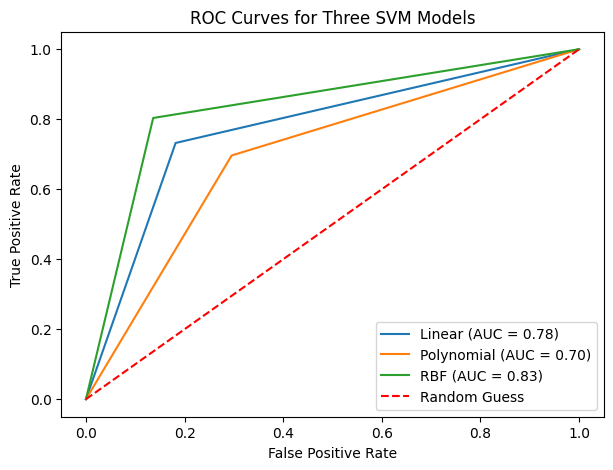

In [40]:
plt.figure(figsize=(7, 5))

for model in ['Linear', 'Polynomial','RBF']:
    fpr, tpr, _ = roc_curve(test1_df['True'], test1_df[model])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'r--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Three SVM Models')
plt.legend()
plt.show()

Increasing the Regularisation value of C to 10, 100 , 1000, 10000 showed no change in Accuracy for Linear Kernel and however detoriated the accuracy of the polynmial Kernel to 0.70.

However, change in the Gamma value from 1 to 0.1 considerably increased the RBL Accuracy  to 0.83 from 0.78, along with Precision and Recall scores.

**Gamma = 1, C = 1**
RBF SVM Accuracy: 0.78
RBF Precision: 0.8035714285714286
RBF Recall (Sensitivity): 0.8035714285714286
RBF F1-Score: 0.8035714285714286

**Gamma = 0.1, C = 1**

RBF SVM Accuracy: 0.83
RBF Precision: 0.8823529411764706
**RBF Recall (Sensitivity): 0.8035714285714286**  --- Higher Recall value denotes lower False negative. And can considered the better at true data classification.
RBF F1-Score: 0.8411214953271028


Few applications of SVM kernels in real time Applications include the below:

**Image Recognition:** Kernels detect textures, edges and fine visual variations, making them useful for classifying objects and visual patterns.

**Text Classification:** Linear kernels handle sparse language features efficiently, helping categorize documents, emails, and sentiment-based text.

**Medical Diagnosis:** RBF kernels identify subtle biological irregularities that may indicate disease, supporting early detection and classification.

**Traffic Anomaly Detection:** Kernels highlight suspicious network behavior, helping cybersecurity systems identify unauthorized access patterns.

**Financial Fraud Analysis: **Kernel boundaries expose unusual payment clusters and transaction behaviors, assisting fraud detection systems.